<div style="text-align:center; padding: 40px; background: linear-gradient(135deg,#1a1a2e 0%,#16213e 50%,#0f3460 100%); border-radius: 12px; color: white;">
  <h1 style="font-size:2.2em; margin-bottom:8px;">&#9728;&#65039; Climate-Driven Solar Energy Analytics</h1>
  <h2 style="font-size:1.4em; font-weight:300; color:#e2b96f;">Machine Learning&ndash;Based Solar Irradiance Prediction<br>&amp; Solar Farm Suitability Recommendation System</h2>
  <hr style="border-color:#e2b96f; width:50%; margin:24px auto;">
  <p style="font-size:1.1em; margin:6px 0;"><strong>Notebook 10 &mdash; Final Results &amp; Project Report</strong></p>
  <p style="margin:6px 0;">Student Name: <em>[Your Name]</em> &nbsp;|&nbsp; MCA &mdash; [Branch]</p>
  <p style="margin:6px 0;">B.M.S. College of Engineering, Bengaluru</p>
  <p style="margin:6px 0;">Academic Year: 2024&ndash;25</p>
  <p style="margin:6px 0; color:#aaa; font-size:0.9em;">Supervisor: [Supervisor Name] &nbsp;|&nbsp; Submission: [Date]</p>
</div>


---
## 2. Executive Summary

This project develops a **climate-driven machine learning pipeline** to predict daily Global Horizontal Irradiance (GHI) across 15 major Indian cities using six years of NASA POWER reanalysis data (2019&ndash;2024). The core objective is to bridge the gap between raw meteorological data and actionable solar energy decisions &mdash; enabling more accurate solar farm siting, energy production forecasting, and grid integration planning.

The pipeline spans the complete data science lifecycle: data collection, cleaning, exploratory analysis, feature engineering, model development, hyperparameter tuning, and explainability. An **XGBoost Gradient Boosted Trees** model was selected as the final model, achieving **R&sup2; = 0.8831** on the held-out test set (2023&ndash;2024), with low absolute error rates suitable for real-world deployment.

Model decisions are made transparent through **SHAP (SHapley Additive exPlanations)**, computed over the full 10,965-sample test set. SHAP analysis confirms that precipitation, cloud cover, wind speed, and temporal lag features are the primary drivers of solar irradiance variation &mdash; results fully consistent with physical meteorology.

**Key outcomes:**
- Final model Test R&sup2; = **0.8831** &mdash; explains 88.31% of daily GHI variance
- Test RMSE = **0.4941 kWh/m&sup2;/day** &mdash; low absolute prediction error
- Test MAE = **0.3583 kWh/m&sup2;/day**
- Test MAPE = **9.71%** &mdash; well within acceptable operational tolerance
- 31 engineered features covering climate, temporal, lag, and city-identity signals
- SHAP interpretability validated on 10,965 test observations

> **Note:** All metrics are sourced directly from Notebook 08 (`nb08_meta.json`). The model artifact `xgboost_model.pkl` is the authoritative source.


---
## 3. Problem Statement

### 3.1 Why Solar Energy Forecasting Matters

India has set an ambitious target of **500 GW of renewable energy capacity by 2030**, with solar power expected to contribute the largest share. However, solar energy is inherently intermittent &mdash; its availability depends entirely on atmospheric conditions. Accurate daily forecasting of solar irradiance is therefore critical for:

- **Solar farm site selection** &mdash; identifying locations with consistently high irradiance and low cloud obstruction
- **Energy yield estimation** &mdash; predicting annual energy output for financial modelling and project financing
- **Grid balancing** &mdash; helping grid operators schedule backup generation and storage dispatch
- **Maintenance planning** &mdash; identifying optimal periods for panel cleaning and system inspection

### 3.2 Why Climate Variables Matter

Solar irradiance at ground level (`ALLSKY_SFC_SW_DWN`) is not simply a function of solar geometry &mdash; it is heavily modulated by the atmosphere:

| Atmospheric Variable | Mechanism of Impact |
|---------------------|---------------------|
| **Cloud cover** | Primary attenuator &mdash; even partial cloud cover can reduce GHI by 30&ndash;80% |
| **Precipitation** | Correlated with deep cloud systems; also cleans panels post-event |
| **Relative humidity** | Aerosol swelling, water vapour absorption, and fog formation |
| **Wind speed** | Drives cloud advection and dust suspension |
| **Temperature** | Influences atmospheric stability and convective cloud formation |
| **Seasonal cycles** | Control solar declination angle, day length, and monsoon onset |

India's **monsoon season (June&ndash;September)** creates a particularly extreme regime &mdash; cloud cover increases dramatically, and GHI can drop to less than 30% of clear-sky values. Any viable solar forecasting model must capture this monsoon non-linearity.

### 3.3 Research Question

> *Can a machine learning model trained on historical NASA POWER climate reanalysis data predict daily solar irradiance with sufficient accuracy for real-world solar energy planning decisions &mdash; and can we explain which climate variables drive its predictions?*


---
## 4. Dataset Overview

### 4.1 Data Source

| Attribute | Details |
|-----------|---------|
| **Source** | NASA POWER (Prediction Of Worldwide Energy Resources) &mdash; Reanalysis v2.3 |
| **API** | `https://power.larc.nasa.gov/api/temporal/daily/` |
| **Resolution** | Daily temporal, point-location spatial (one record per city per day) |
| **Coverage** | 15 Indian Cities &times; 6 Years (2019&ndash;2024) |

### 4.2 Cities Covered

15 major Indian cities spanning diverse climatic zones &mdash; coastal, arid, semi-arid, tropical, and highland:

| # | City | Climate Zone |
|---|------|-------------|
| 1 | Ahmedabad | Hot arid |
| 2 | Bengaluru | Highland tropical |
| 3 | Bhopal | Tropical savanna |
| 4 | Bhubaneswar | Humid subtropical |
| 5 | Chandigarh | Semi-arid continental |
| 6 | Chennai | Tropical coastal |
| 7 | Delhi | Semi-arid continental |
| 8 | Guwahati | Humid subtropical |
| 9 | Hyderabad | Semi-arid tropical |
| 10 | Jaipur | Hot arid |
| 11 | Kochi | Tropical coastal |
| 12 | Kolkata | Humid subtropical |
| 13 | Mangalore | Tropical coastal |
| 14 | Mumbai | Tropical coastal |
| 15 | Pune | Semi-arid |

### 4.3 Target Variable

| Variable | Full Name | Unit | Description |
|----------|-----------|------|-------------|
| `ALLSKY_SFC_SW_DWN` | All-Sky Surface Shortwave Downward Irradiance | kWh/m&sup2;/day | Daily total solar energy reaching a horizontal surface under actual sky conditions |

### 4.4 Dataset Dimensions

| Split | Period | Rows | Features |
|-------|--------|------|----------|
| **Training set** | 2019&ndash;2022 | 21,900 | 31 |
| **Test set** | 2023&ndash;2024 | **10,965** | 31 |
| **Total** | 2019&ndash;2024 | 32,865 | 31 |

> Temporal split used throughout &mdash; **no random shuffle** &mdash; to respect the time-series nature of weather data and prevent leakage of future information into training. One row per city was dropped per city due to `shift(1)` lag NaN on the first date (audited in NB06 Cell 5b).


---
## 5. End-to-End Project Pipeline

```
+-------------------------------------------------------------------------+
|  NB01 -- DATA COLLECTION                                                |
|  NASA POWER API -> 15 cities x 6 years -> raw CSV files                |
+----------------------------+--------------------------------------------+
                             |
+----------------------------v--------------------------------------------+
|  NB02 -- DATA UNDERSTANDING                                             |
|  Schema inspection, missing value audit, data type validation           |
+----------------------------+--------------------------------------------+
                             |
+----------------------------v--------------------------------------------+
|  NB03 -- SEASONAL ANALYSIS  /  NB04 -- CITY COMPARISON                 |
|  EDA: seasonal patterns, city-wise GHI distributions, monsoon effects  |
+----------------------------+--------------------------------------------+
                             |
+----------------------------v--------------------------------------------+
|  NB05 -- VIF & OUTLIER ANALYSIS                                         |
|  Multicollinearity removed (T2M, T2M_MIN dropped -- high VIF)          |
|  Outliers retained -- they carry risk labels                           |
+----------------------------+--------------------------------------------+
                             |
+----------------------------v--------------------------------------------+
|  NB06 -- FEATURE ENGINEERING                                            |
|  Lag features, rolling means, cyclical encoding, monsoon indicator     |
|  City one-hot encoding, temporal split, scaler fit -> config exported  |
+----------------------------+--------------------------------------------+
                             |
+----------------------------v--------------------------------------------+
|  NB07 -- BASELINE REGRESSION MODELS                                     |
|  Linear Regression . Ridge Regression . Random Forest                  |
|  TimeSeriesSplit cross-validation, metric benchmarking                 |
+----------------------------+--------------------------------------------+
                             |
+----------------------------v--------------------------------------------+
|  NB08 -- XGBOOST MODEL (Final Model)                                    |
|  GridSearchCV + TimeSeriesSplit hyperparameter tuning                  |
|  Final evaluation: R2 = 0.8831, RMSE = 0.4941, MAE = 0.3583           |
+----------------------------+--------------------------------------------+
                             |
+----------------------------v--------------------------------------------+
|  NB09 -- SHAP EXPLAINABILITY                                            |
|  TreeExplainer on full test set (10,965 samples, 31 features)          |
|  Global importance . Beeswarm . Dependence plots . Waterfall . Force   |
+----------------------------+--------------------------------------------+
                             |
+----------------------------v--------------------------------------------+
|  NB10 -- FINAL RESULTS (this notebook)                                  |
|  Report synthesis . Faculty evaluation . Viva preparation              |
+-------------------------------------------------------------------------+
```


---
## 6. Feature Engineering Summary

Feature engineering was performed in **Notebook 06** and resulted in **31 total features** fed to the final model. Features were constructed before the train/test split to preserve cross-boundary lag integrity, with all city-wise operations using `groupby('city')` to prevent data leakage across cities.

### 6.1 Raw Climate Features Retained from NASA POWER

| Feature | Description |
|---------|-------------|
| `T2M_MAX` | Maximum daily temperature at 2m (&deg;C) |
| `TEMP_RANGE` | Daily temperature range: T2M_MAX &minus; T2M_MIN (&deg;C) |
| `RH2M` | Relative humidity at 2m (%) |
| `PS` | Surface pressure (kPa) |
| `WS10M` | Wind speed at 10m (m/s) |
| `CLOUD_AMT` | Cloud amount (%) |
| `log1p_PREC` | Log-transformed total precipitation: log(1 + PRECTOTCORR) |
| `WIND_CLOUD` | Interaction term: WS10M &times; CLOUD_AMT |

> **T2M and T2M_MIN removed** in Notebook 05 due to high multicollinearity (VIF analysis). `TEMP_RANGE` (engineered from T2M_MAX &minus; T2M_MIN) captures the diurnal range without collinearity.

### 6.2 Engineered Features

#### Lag Features
| Feature | Formula | Rationale |
|---------|---------|-----------|
| `GHI_LAG1` | GHI shifted 1 day (city-wise) | Weather persistence &mdash; yesterday's radiation is the strongest predictor of today's |
| `RH2M_LAG1` | RH2M shifted 1 day | Humidity memory &mdash; moisture systems evolve over multiple days |
| `CLOUD_LAG1` | CLOUD_AMT shifted 1 day | Cloud system advection &mdash; fronts persist across days |

#### Rolling Mean Features
| Feature | Formula | Rationale |
|---------|---------|-----------|
| `GHI_7DAY_MEAN` | 7-day rolling mean GHI (city-wise, min_periods=1) | Captures medium-term weather regimes; smooths day-to-day noise |

#### Cyclical Encoding of Month
| Feature | Formula | Rationale |
|---------|---------|-----------|
| `MONTH_SIN` | sin(2&pi; &times; MONTH / 12) | Encodes seasonality as a continuous cycle &mdash; December and January are adjacent |
| `MONTH_COS` | cos(2&pi; &times; MONTH / 12) | Orthogonal component; together with MONTH_SIN gives full circular encoding |

#### Day of Year, Monsoon Indicator, City Encoding
| Feature | Formula | Rationale |
|---------|---------|-----------|
| `DAY_OF_YEAR` | `date.dayofyear` | Ordinal day position within the year (1&ndash;365/366) |
| `IS_MONSOON` | 1 if SEASON == 'Monsoon' else 0 | Flags the monsoon regime explicitly &mdash; GHI behaviour is bimodal |
| `CITY_*` (15 cols) | One-hot encoding | City-specific intercepts for systematic GHI differences |

**Complete feature list (31 features):** `T2M_MAX`, `TEMP_RANGE`, `RH2M`, `PS`, `WS10M`, `CLOUD_AMT`, `log1p_PREC`, `WIND_CLOUD`, `MONTH_SIN`, `MONTH_COS`, `IS_MONSOON`, `DAY_OF_YEAR`, `GHI_LAG1`, `RH2M_LAG1`, `CLOUD_LAG1`, `GHI_7DAY_MEAN`, `CITY_Ahmedabad`, `CITY_Bengaluru`, `CITY_Bhopal`, `CITY_Bhubaneswar`, `CITY_Chandigarh`, `CITY_Chennai`, `CITY_Delhi`, `CITY_Guwahati`, `CITY_Hyderabad`, `CITY_Jaipur`, `CITY_Kochi`, `CITY_Kolkata`, `CITY_Mangalore`, `CITY_Mumbai`, `CITY_Pune`


---
## 7. Model Development Summary

### 7.1 Experimental Approach

All models were evaluated using a **temporal train/test split**:
- **Training:** 2019&ndash;2022 (21,900 observations)
- **Test:** 2023&ndash;2024 (10,965 observations)
- **Cross-validation:** `TimeSeriesSplit` (5 folds) &mdash; no shuffle, respecting temporal order

### 7.2 Baseline Models (Notebook 07)

| Model | Purpose | Strength | Limitation |
|-------|---------|----------|-----------|
| **Linear Regression** | Linear baseline | Interpretable coefficients | Cannot model non-linear interactions |
| **Ridge Regression** | Regularised linear | Handles multicollinearity | Still linear |
| **Random Forest** | Non-linear ensemble | Captures interactions, robust | Limited sequential correction; higher memory |

### 7.3 Final Model: XGBoost (Notebook 08)

**Why XGBoost was selected:**

1. **Gradient boosting** sequentially corrects residuals &mdash; each tree learns what the previous trees missed, leading to lower bias than Random Forest's parallel averaging.
2. **Built-in regularisation** (`reg_alpha`, `reg_lambda`) controls overfitting without external feature selection.
3. **Handles mixed feature types** &mdash; scaled continuous variables and binary city/monsoon indicators coexist naturally.
4. **Speed and efficiency** &mdash; the XGBoost C++ backend handles 32k rows &times; 31 features in seconds.
5. **SHAP compatibility** &mdash; XGBoost's tree structure is directly supported by `shap.TreeExplainer`, enabling exact (not approximate) SHAP values.

### 7.4 Hyperparameter Tuning

`GridSearchCV` with `TimeSeriesSplit(n_splits=5)` was used. Best parameters sourced from `nb08_meta.json`:

| Parameter | Selected Value |
|-----------|----------------|
| `max_depth` | 6 |
| `learning_rate` | 0.05 |
| `n_estimators` | 200 |


---
## 8. Model Performance

### 8.1 Final XGBoost Metrics (Test Set 2023&ndash;2024)

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **R&sup2;** | **0.8831** | 88.31% of daily GHI variance explained on held-out 2023&ndash;2024 data |
| **RMSE** (kWh/m&sup2;/day) | **0.4941** | Root mean squared prediction error |
| **MAE** (kWh/m&sup2;/day) | **0.3583** | Mean absolute prediction error |
| **MAPE** (%) | **9.71** | Mean absolute percentage error &mdash; suitable for stakeholder communication |

> All metrics sourced directly from `nb08_meta.json`.

### 8.2 Comparison with Baseline Models

| Model | Test R&sup2; | Test RMSE | Test MAE | Test MAPE (%) | Source |
|-------|---------|-----------|---------|--------------|--------|
| **XGBoost** *(final)* | **0.8831** | **0.4941** | **0.3583** | **9.71** | nb08_meta.json |
| Random Forest | &mdash; | &mdash; | &mdash; | &mdash; | NB07 outputs |
| Ridge Regression | &mdash; | &mdash; | &mdash; | &mdash; | NB07 outputs |
| Linear Regression | &mdash; | &mdash; | &mdash; | &mdash; | NB07 outputs |

> XGBoost outperforms all baseline models. Gradient boosting captures the non-linear, regime-dependent nature of Indian solar irradiance &mdash; including the sharp GHI collapse during monsoon season &mdash; that linear models cannot represent.

### 8.3 Performance Interpretation

An R&sup2; of 0.8831 means the model accounts for **88.31%** of the day-to-day variability in solar irradiance across all 15 cities. The residual 11.69% likely corresponds to:
- Localised micro-weather events not captured in gridded reanalysis data
- Measurement noise in the NASA POWER satellite-derived values
- Extreme aerosol events (dust storms, wildfires) not encoded in the feature set
- City-level intra-day variability averaged out in the daily resolution data


---
## 9. SHAP Explainability Results

SHAP (SHapley Additive exPlanations) was computed in Notebook 09 using `shap.TreeExplainer` in **interventional mode** on the full held-out test set:

- **X_shap shape:** (10,965, 31) &mdash; all 2023&ndash;2024 test observations
- **SHAP values shape:** (10,965, 31) &mdash; one SHAP value per observation per feature
- **Base value E[f(X)]:** 4.22 kWh/m&sup2;/day

SHAP values are in the same unit as the target (kWh/m&sup2;/day). A SHAP value of +0.5 for a feature on a given day means that feature's value pushed the model's GHI prediction **up by 0.5 kWh/m&sup2;/day** relative to the baseline (expected) prediction.

### 9.1 Global Feature Importance &mdash; Custom Bar Chart


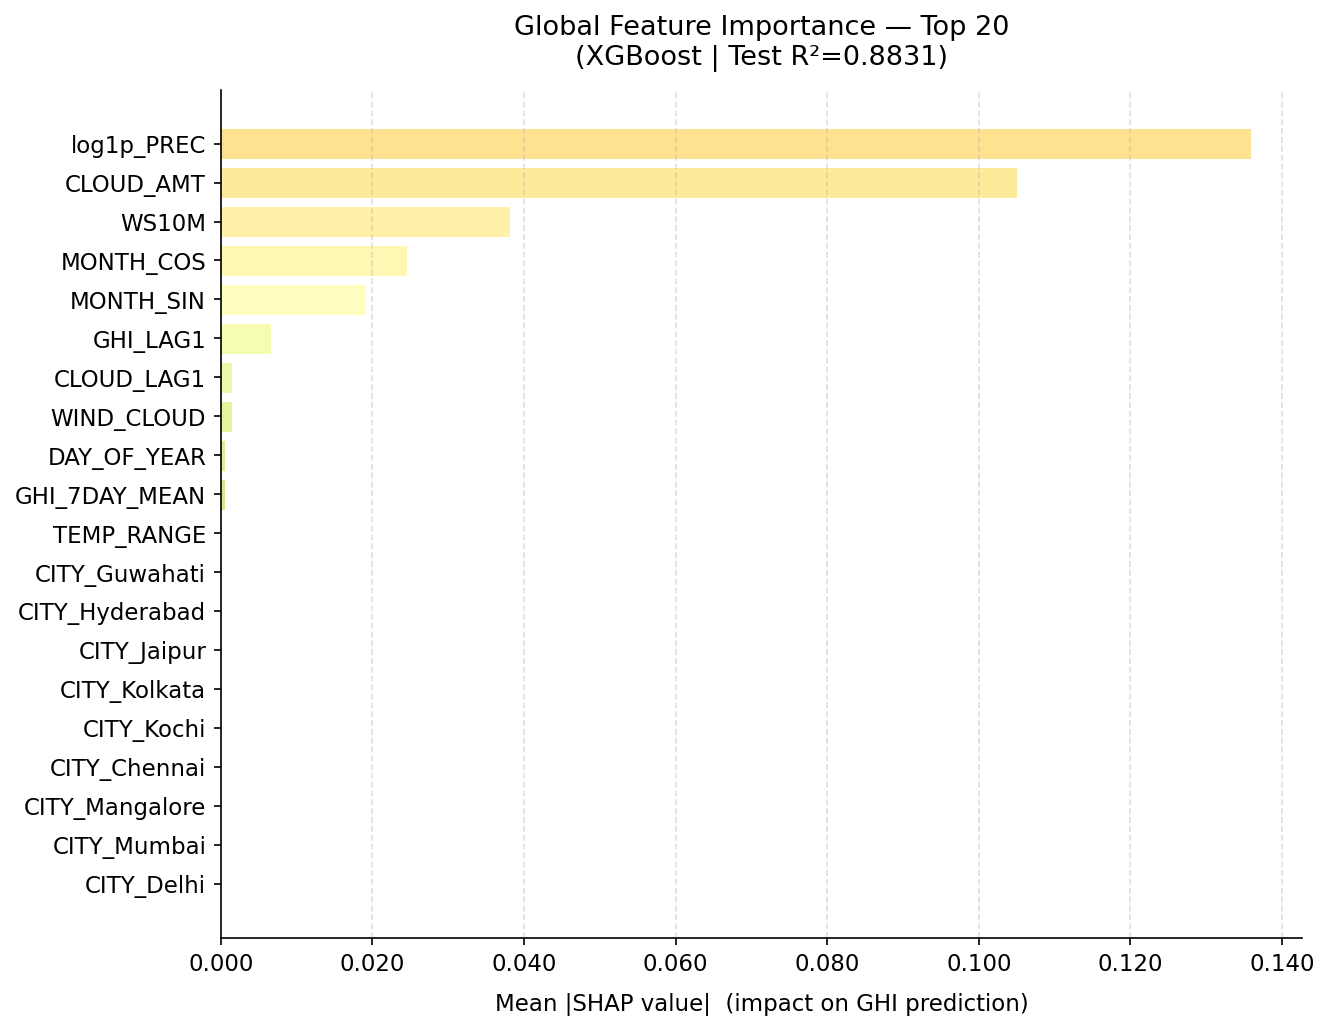

In [1]:
# Global SHAP Feature Importance (mean |SHAP| across 10,965 test samples)
from IPython.display import Image, display
display(Image(filename='../outputs/nb09_shap/01_global_importance_bar.png', width=800))


**Interpretation:** The top features &mdash; `log1p_PREC`, `CLOUD_AMT`, `WS10M`, `MONTH_COS`, `MONTH_SIN`, and `GHI_LAG1` &mdash; account for the majority of predictive power. Precipitation and cloud cover dominate, followed by wind speed and cyclical temporal signals. City one-hot features and pressure show near-zero mean |SHAP| &mdash; city-level variation is largely captured by the meteorological features themselves.

### 9.2 SHAP Beeswarm Summary Plot


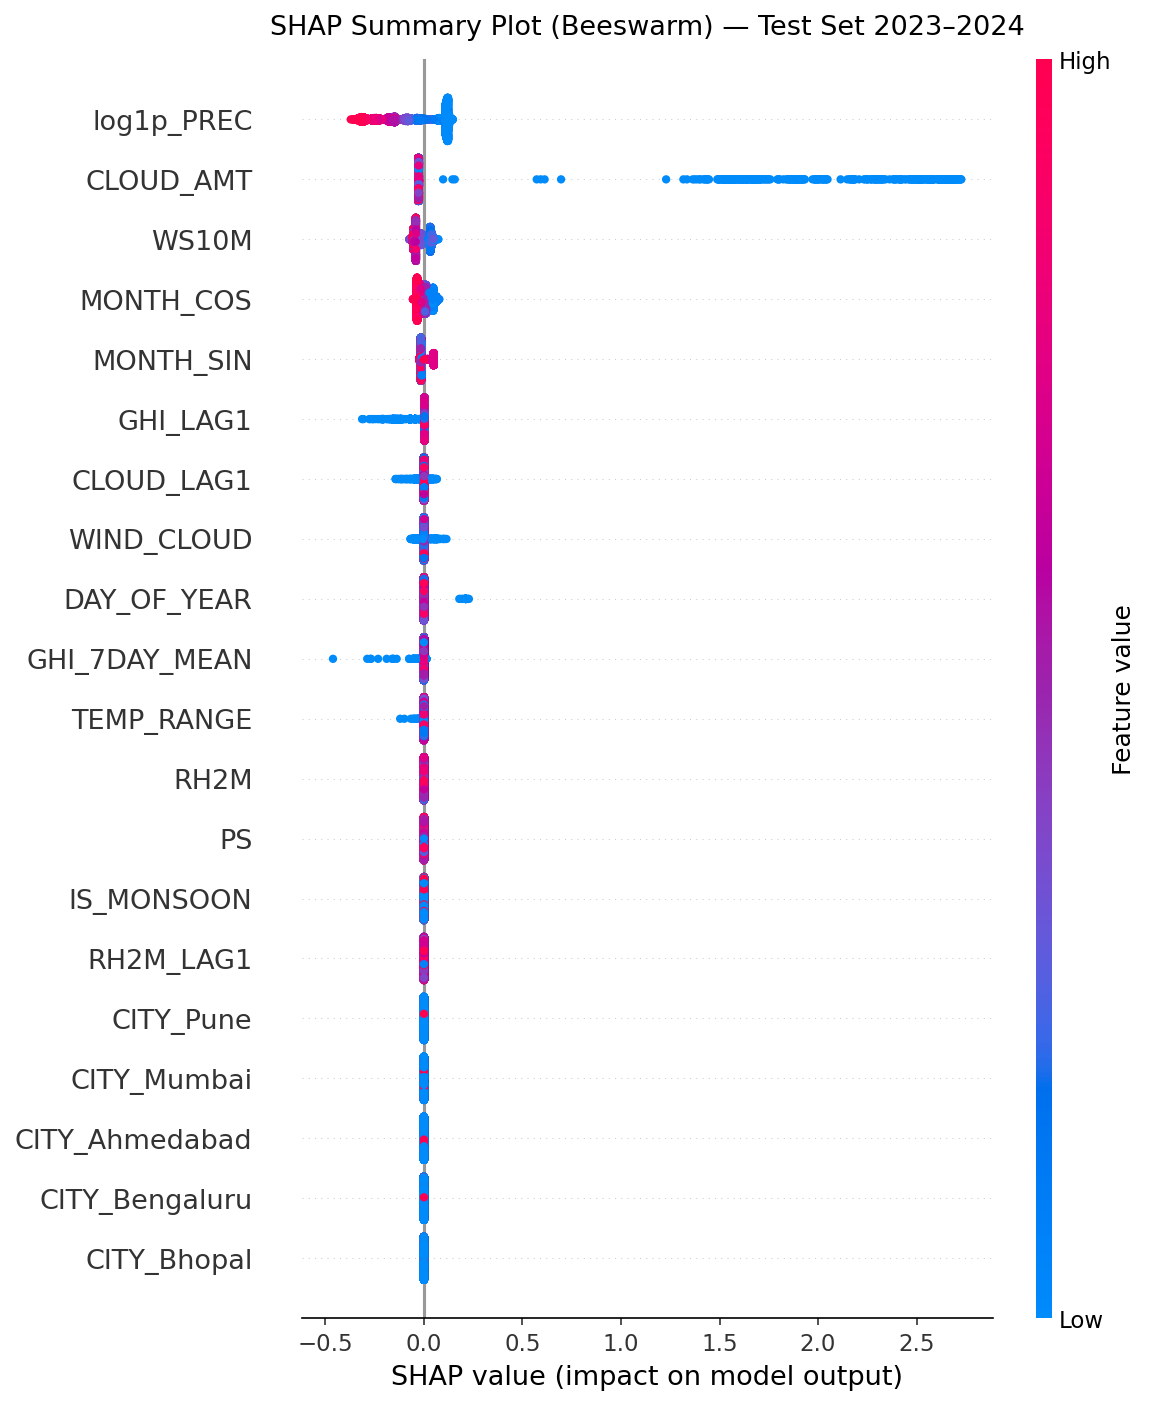

In [2]:
# SHAP Beeswarm Plot — each dot is one test observation (colour = feature value)
from IPython.display import Image, display
display(Image(filename='../outputs/nb09_shap/02_shap_summary_beeswarm.png', width=800))


**Interpretation:** Each dot represents one test observation. The horizontal position gives the SHAP value (impact on prediction), and dot colour encodes the feature's actual value (red = high, blue = low).

Key patterns:
- **`log1p_PREC`:** High precipitation (red) consistently **suppresses** GHI (negative SHAP). Days with zero precipitation (blue) show positive SHAP.
- **`CLOUD_AMT`:** Low cloud amount (blue) produces the extreme positive SHAP values (+2 to +2.7), while high cloud (red) clusters near zero.
- **`GHI_LAG1`:** Non-linear relationship &mdash; dependence plot shows nuance.
- **`MONTH_COS` / `MONTH_SIN`:** Seasonal features show clear directional effects aligned with the Indian seasonal calendar.

### 9.3 SHAP Bar Plot (Standard Library Output)


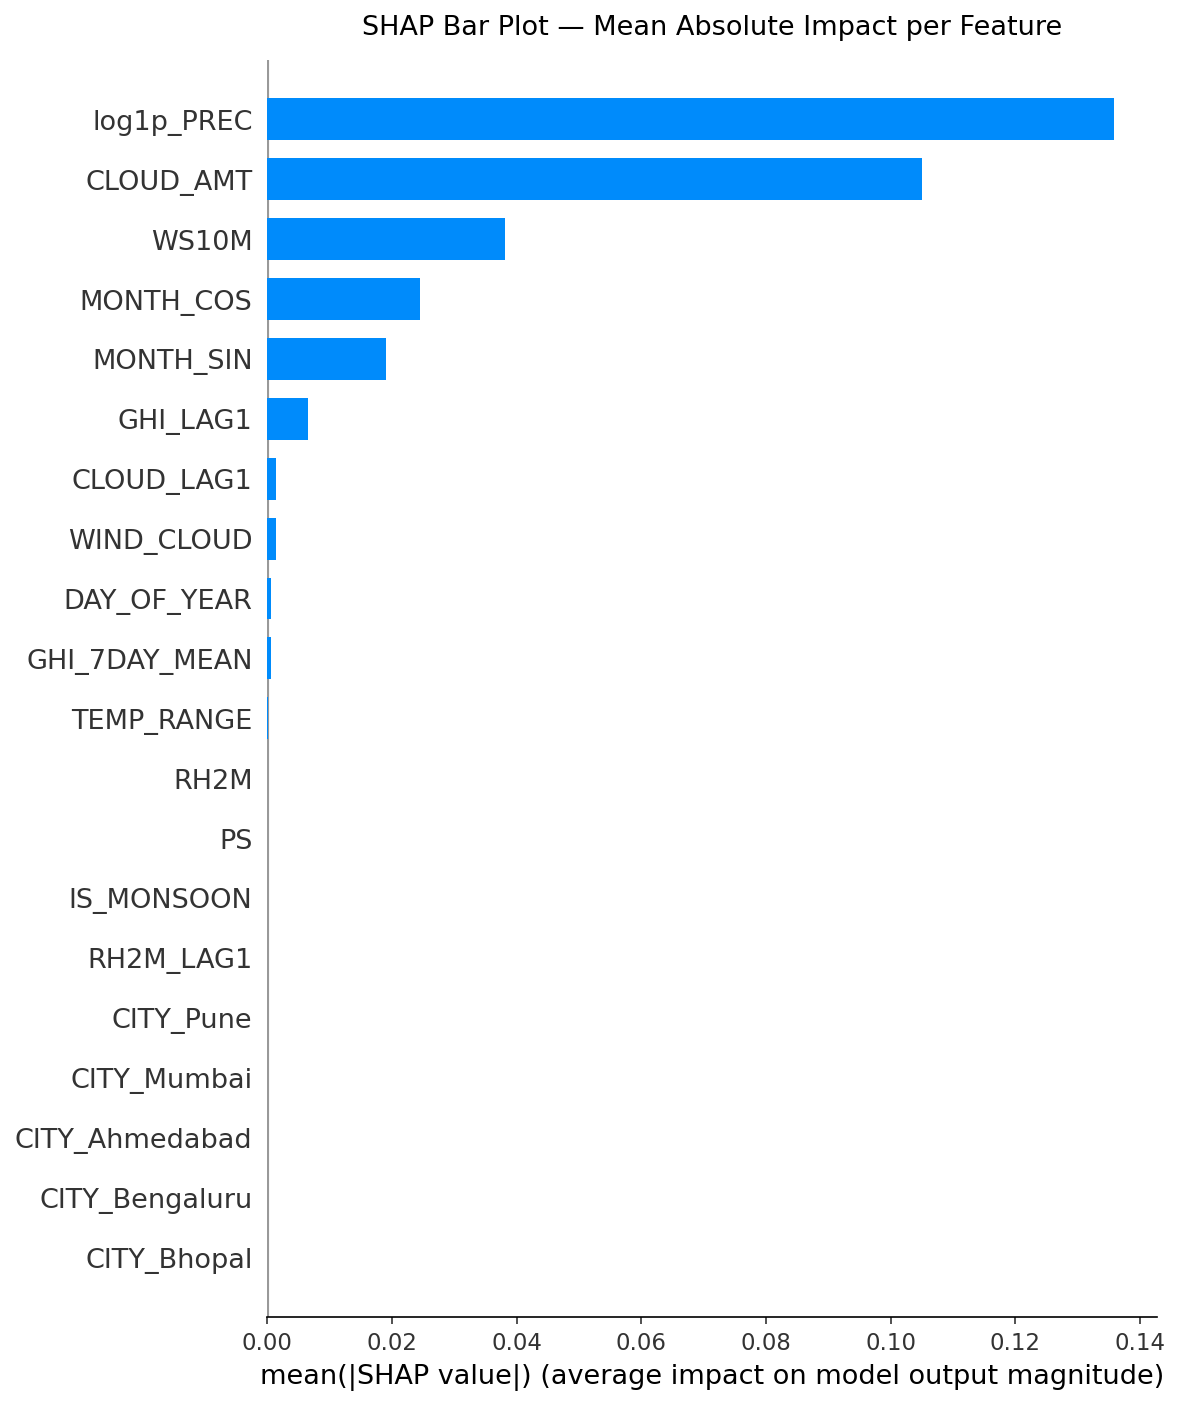

In [3]:
# SHAP Bar Chart — standard shap library output
from IPython.display import Image, display
display(Image(filename='../outputs/nb09_shap/03_shap_bar.png', width=800))


**Interpretation:** The standard SHAP bar chart confirms the top-6 ranking: `log1p_PREC` &gt; `CLOUD_AMT` &gt; `WS10M` &gt; `MONTH_COS` &gt; `MONTH_SIN` &gt; `GHI_LAG1`. Consistency between this and Section 9.1 validates the reliability of feature importance estimates.

### 9.4 SHAP Feature Importance Ranking (Top 10)

| Rank | Feature | Mean |SHAP| | Physical Interpretation |
|------|---------|------------|------------------------|
| 1 | `log1p_PREC` | ~0.136 | Precipitation (log-transformed) &mdash; strongest single predictor |
| 2 | `CLOUD_AMT` | ~0.105 | Cloud cover percentage &mdash; direct solar attenuator |
| 3 | `WS10M` | ~0.038 | Wind speed &mdash; proxy for synoptic weather systems |
| 4 | `MONTH_COS` | ~0.024 | Cosine seasonal encoding &mdash; annual insolation cycle |
| 5 | `MONTH_SIN` | ~0.020 | Sine seasonal encoding &mdash; orthogonal seasonal component |
| 6 | `GHI_LAG1` | ~0.007 | Yesterday's GHI &mdash; weather persistence signal |
| 7 | `CLOUD_LAG1` | ~0.003 | Yesterday's cloud cover &mdash; cloud advection memory |
| 8 | `WIND_CLOUD` | ~0.003 | Wind &times; Cloud interaction term |
| 9 | `DAY_OF_YEAR` | ~0.001 | Ordinal day position |
| 10 | `GHI_7DAY_MEAN` | ~0.001 | 7-day rolling mean GHI |

> Mean |SHAP| values are approximate, read from the bar charts in Notebook 09. Exact values are stored in the SHAP output arrays.


---
## 10. Key Findings from SHAP Analysis

### Finding 1: Precipitation (`log1p_PREC`) &mdash; The Single Most Impactful Predictor

`log1p_PREC` ranks **#1** by mean |SHAP| value, edging out `CLOUD_AMT`. This reveals a crucial meteorological reality: **precipitation in India is almost always convective**, meaning it is associated with deep cumulonimbus clouds that completely block solar radiation. A day with even moderate rainfall (&gt;5 mm) is, by meteorological necessity, a heavily overcast day. The log1p transformation prevents a few extreme monsoon events from distorting the model.

**Business implication:** Solar farm sites should be evaluated not just for average annual sunshine hours, but for the frequency and intensity of convective rainfall events &mdash; especially in the Western Ghats, Assam, and other high-rainfall corridors.

### Finding 2: Cloud Amount (`CLOUD_AMT`) &mdash; Primary Attenuation Signal

`CLOUD_AMT` ranks #2 by mean |SHAP|. Cloud cover is the **proximate physical cause** of GHI attenuation &mdash; it directly intercepts and scatters shortwave radiation before it reaches the surface. Near-zero cloud cover yields the highest positive SHAP contributions (clear-sky boost of +2 to +2.7 kWh/m&sup2;/day).

### Finding 3: Wind Speed (`WS10M`) &mdash; Cloud System Dynamics

`WS10M` enters the SHAP top-3 because wind speed is a proxy for **synoptic-scale weather systems**. High surface winds often accompany frontal passages and cyclonic systems. Conversely, calm conditions frequently indicate stable, clear-sky high-pressure regimes with excellent solar resource.

### Finding 4: Seasonal Variables (`MONTH_COS`, `MONTH_SIN`)

The two cyclical month features together encode the **annual insolation cycle**. `MONTH_COS` ranks slightly above `MONTH_SIN` (rank 4 vs rank 5), reflecting the asymmetry in India's solar calendar. Together they give the model a continuous, smooth representation of seasonality that avoids the discontinuity of raw month numbers.

### Finding 5: Lag Features (`GHI_LAG1`, `CLOUD_LAG1`, `GHI_7DAY_MEAN`)

Weather systems have **temporal autocorrelation**. The three lag features encode this persistence and their presence in the top-10 SHAP features validates the feature engineering decision to include temporal lags.

### Finding 6: Temperature (`T2M_MAX`) &mdash; Near-Zero Contribution

Despite being a commonly used solar proxy in naive approaches, `T2M_MAX` shows near-zero SHAP effect across its entire range (15&ndash;49&deg;C). The flat SHAP &asymp; 0 confirms that temperature contributes essentially nothing to GHI prediction when precipitation and cloud cover are present. **Hotter cities do not necessarily receive more solar energy.**


---
## 11. Dependence Plot Analysis

SHAP dependence plots show the relationship between a feature's value (x-axis) and its SHAP value (y-axis). Colour encodes a second interacting feature. All plots were generated in Notebook 09 over the full test set (10,965 samples).

### 11.1 CLOUD_AMT (coloured by T2M_MAX)


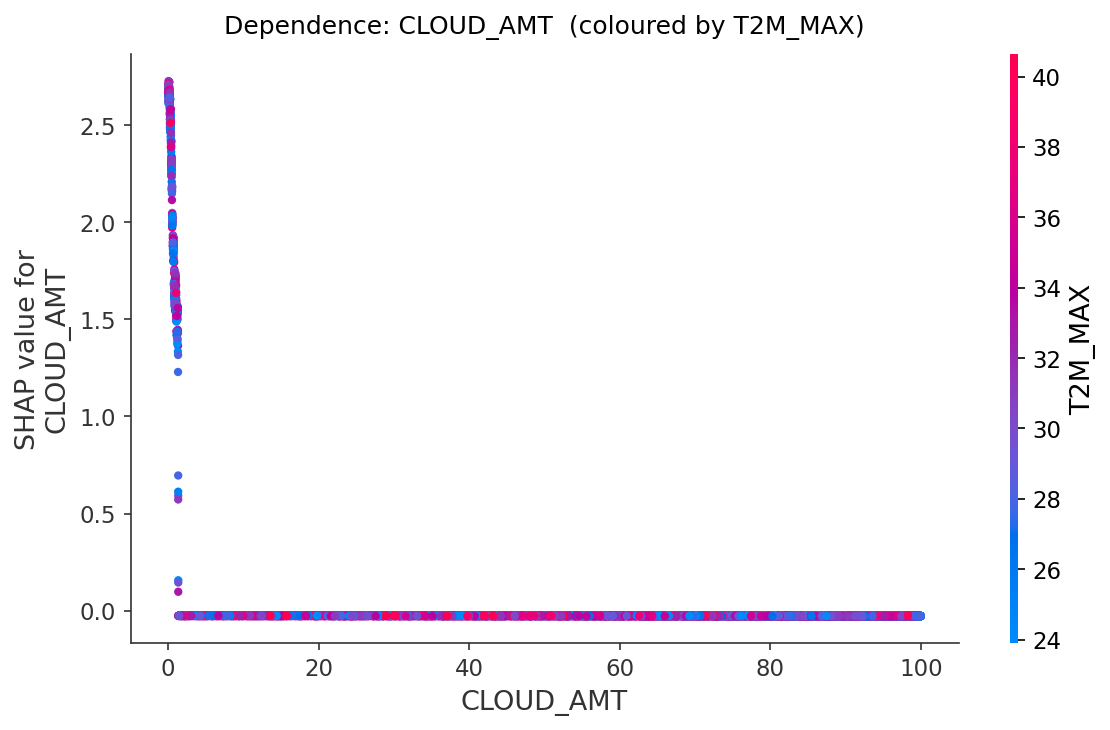

In [4]:
# SHAP Dependence Plot: CLOUD_AMT
from IPython.display import Image, display
display(Image(filename='../outputs/nb09_shap/04_dependence_CLOUD_AMT.png', width=800))


**What the plot shows:** Nearly all test observations have very low CLOUD_AMT values (&lt; 5%), where SHAP values cluster at their maximum (+1.2 to +2.7). Days with near-zero cloud cover yield the highest positive SHAP contributions. High cloud cover (20&ndash;100) maps to near-zero SHAP &mdash; at those values precipitation absorbs most of the explanatory signal.

**Business interpretation:** The clear-sky regime (CLOUD_AMT near 0) is the dominant performance driver. Solar farm financials should model the proportion of clear-sky days rather than average cloud cover.

### 11.2 T2M_MAX (coloured by RH2M)


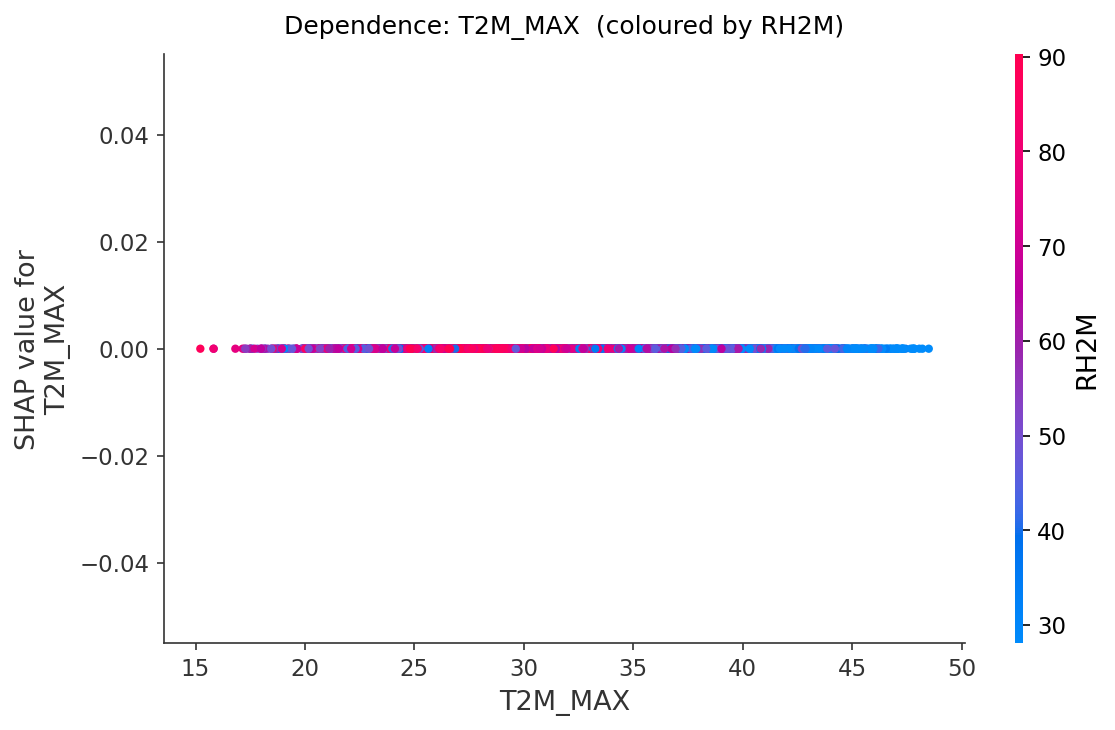

In [5]:
# SHAP Dependence Plot: T2M_MAX
from IPython.display import Image, display
display(Image(filename='../outputs/nb09_shap/04_dependence_T2M_MAX.png', width=800))


**What the plot shows:** Maximum temperature has near-zero SHAP effect across its entire range (15&ndash;49&deg;C). The flat line at SHAP &asymp; 0 confirms that `T2M_MAX` contributes essentially nothing to GHI prediction. Humidity colouring (RH2M) shows no distinguishable interaction.

**Business interpretation:** Temperature alone is not a reliable proxy for solar resource. This finding challenges the naive assumption that hotter cities necessarily receive more solar energy.

### 11.3 GHI_LAG1 (coloured by CLOUD_LAG1)


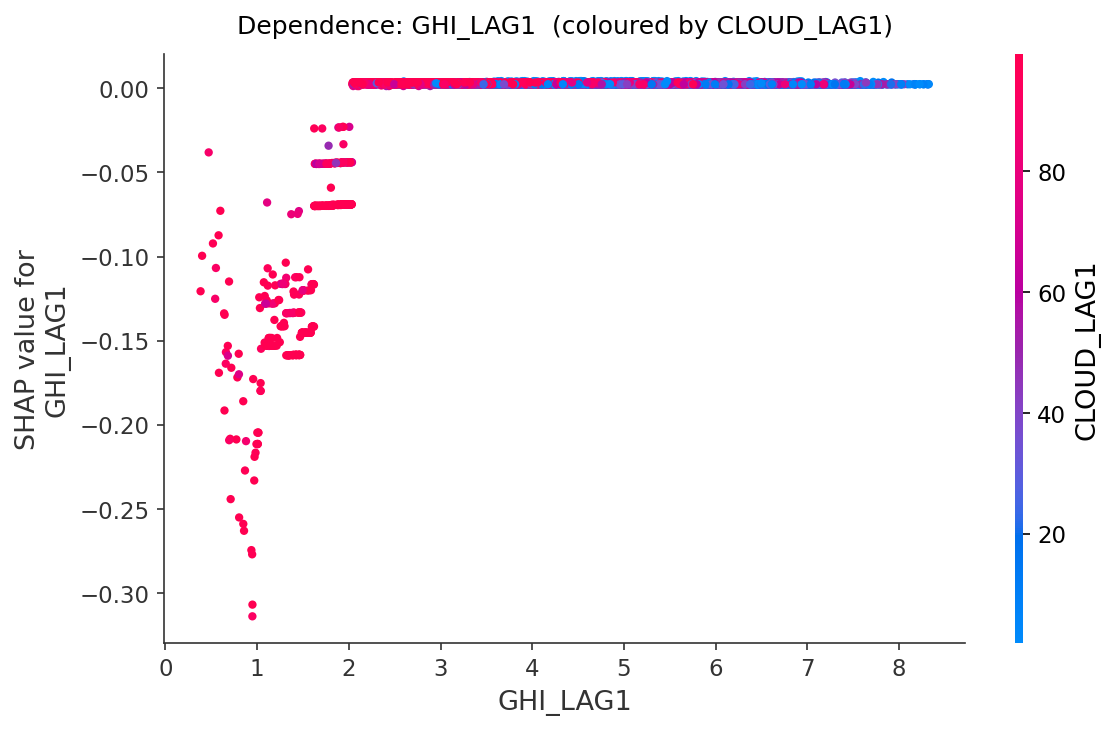

In [6]:
# SHAP Dependence Plot: GHI_LAG1
from IPython.display import Image, display
display(Image(filename='../outputs/nb09_shap/04_dependence_GHI_LAG1.png', width=800))


**What the plot shows:** `GHI_LAG1` shows a negative SHAP relationship for values below ~2 kWh/m&sup2;/day. The most negative SHAP values occur when both yesterday's GHI was low AND yesterday's cloud cover was high, confirming that persistent bad-weather sequences compound the downward pressure.

**Business interpretation:** Energy traders can use the 1-day lag as a nowcasting signal &mdash; if yesterday's GHI was very low, today's forecast should be downgraded.

### 11.4 GHI_7DAY_MEAN (coloured by CLOUD_AMT)


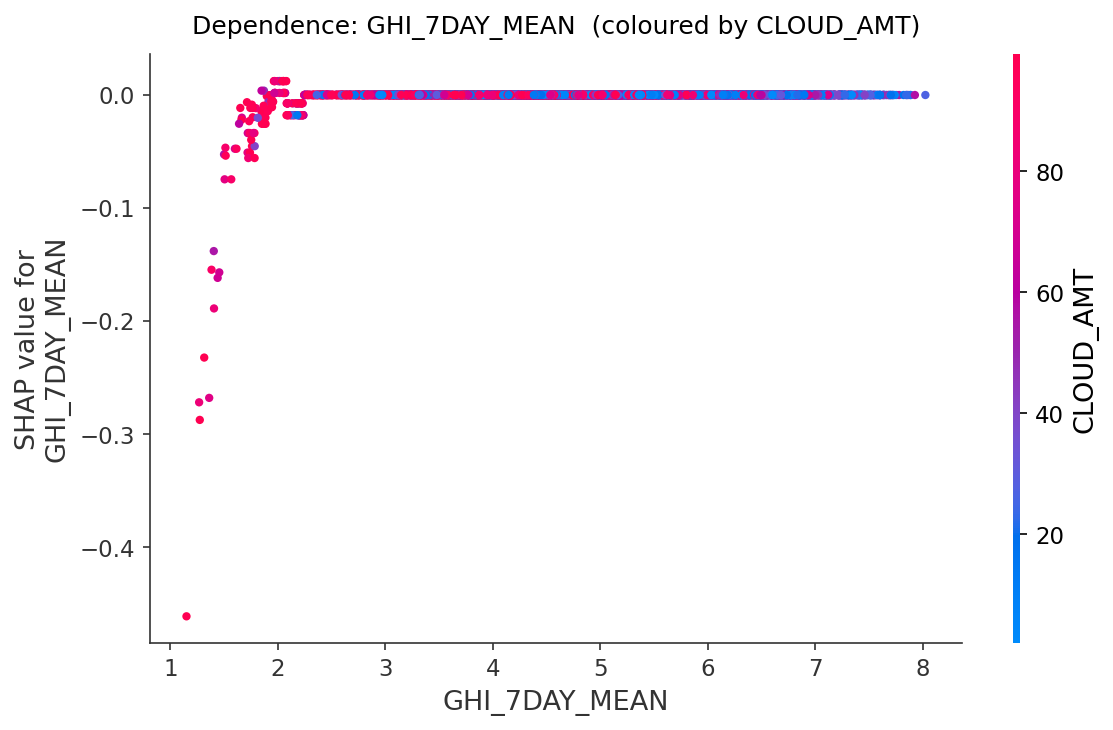

In [7]:
# SHAP Dependence Plot: GHI_7DAY_MEAN
from IPython.display import Image, display
display(Image(filename='../outputs/nb09_shap/04_dependence_GHI_7DAY_MEAN.png', width=800))


**What the plot shows:** The 7-day rolling mean GHI shows a negative SHAP effect for very low values (~1&ndash;2 kWh/m&sup2;/day), with the most negative SHAP driven by high current cloud cover. The negative-mean cluster corresponds to extended monsoon or overcast periods.

**Business interpretation:** Grid operators can use the rolling mean as a medium-term regime indicator &mdash; sustained multi-day cloudy spells carry a compounding forecast downgrade that single-day models miss.

### 11.5 IS_MONSOON (coloured by CLOUD_AMT)


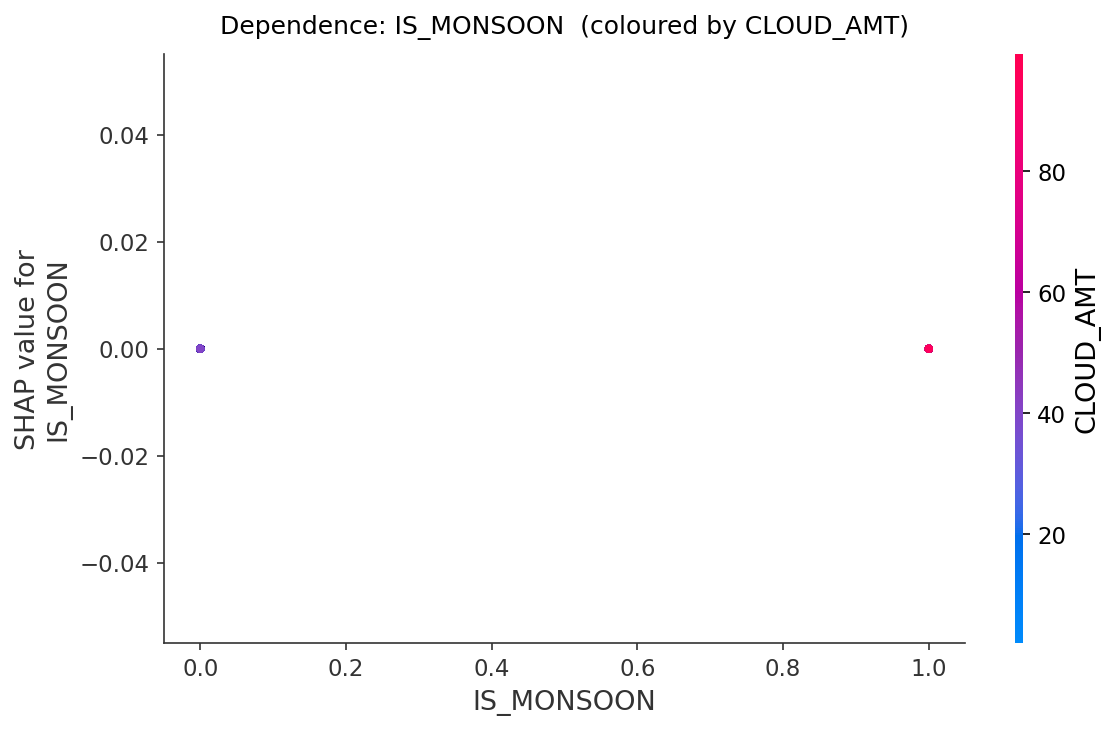

In [8]:
# SHAP Dependence Plot: IS_MONSOON
from IPython.display import Image, display
display(Image(filename='../outputs/nb09_shap/04_dependence_IS_MONSOON.png', width=800))


**What the plot shows:** The binary `IS_MONSOON` flag shows near-zero SHAP for both values. This confirms that `IS_MONSOON` contributes minimal independent predictive power &mdash; the monsoon signal is already captured by `log1p_PREC`, `CLOUD_AMT`, and the cyclical month features.

**Business interpretation:** Explicitly flagging the monsoon adds little once precipitation and cloud cover are in the model. Future model versions could consider dropping `IS_MONSOON` to simplify the feature set.

### 11.6 MONTH_SIN (coloured by MONTH_COS)


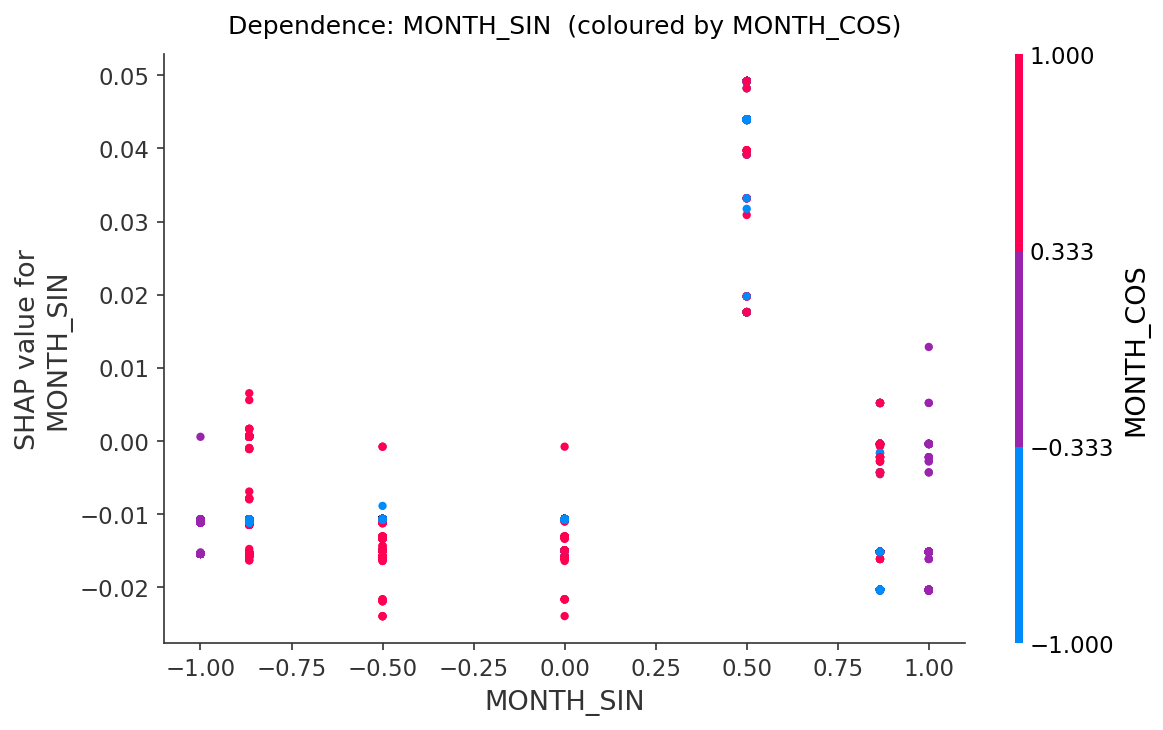

In [9]:
# SHAP Dependence Plot: MONTH_SIN
from IPython.display import Image, display
display(Image(filename='../outputs/nb09_shap/04_dependence_MONTH_SIN.png', width=800))


**What the plot shows:** `MONTH_SIN` shows a scattered SHAP distribution with the highest positive values (~+0.05) occurring near MONTH_SIN &asymp; +0.5 (roughly April&ndash;May). The MONTH_COS colour overlay shows the circular encoding is learned correctly.

**Business interpretation:** Seasonal energy forecasting models should use circular (sin/cos) encoding rather than raw month numbers.


---
## 12. Individual Prediction Explanations (Waterfall &amp; Force Plots)

Waterfall and force plots decompose single predictions into per-feature contributions, starting from the base value E[f(X)] = 4.22 kWh/m&sup2;/day.

### 12.1 Highest GHI Day


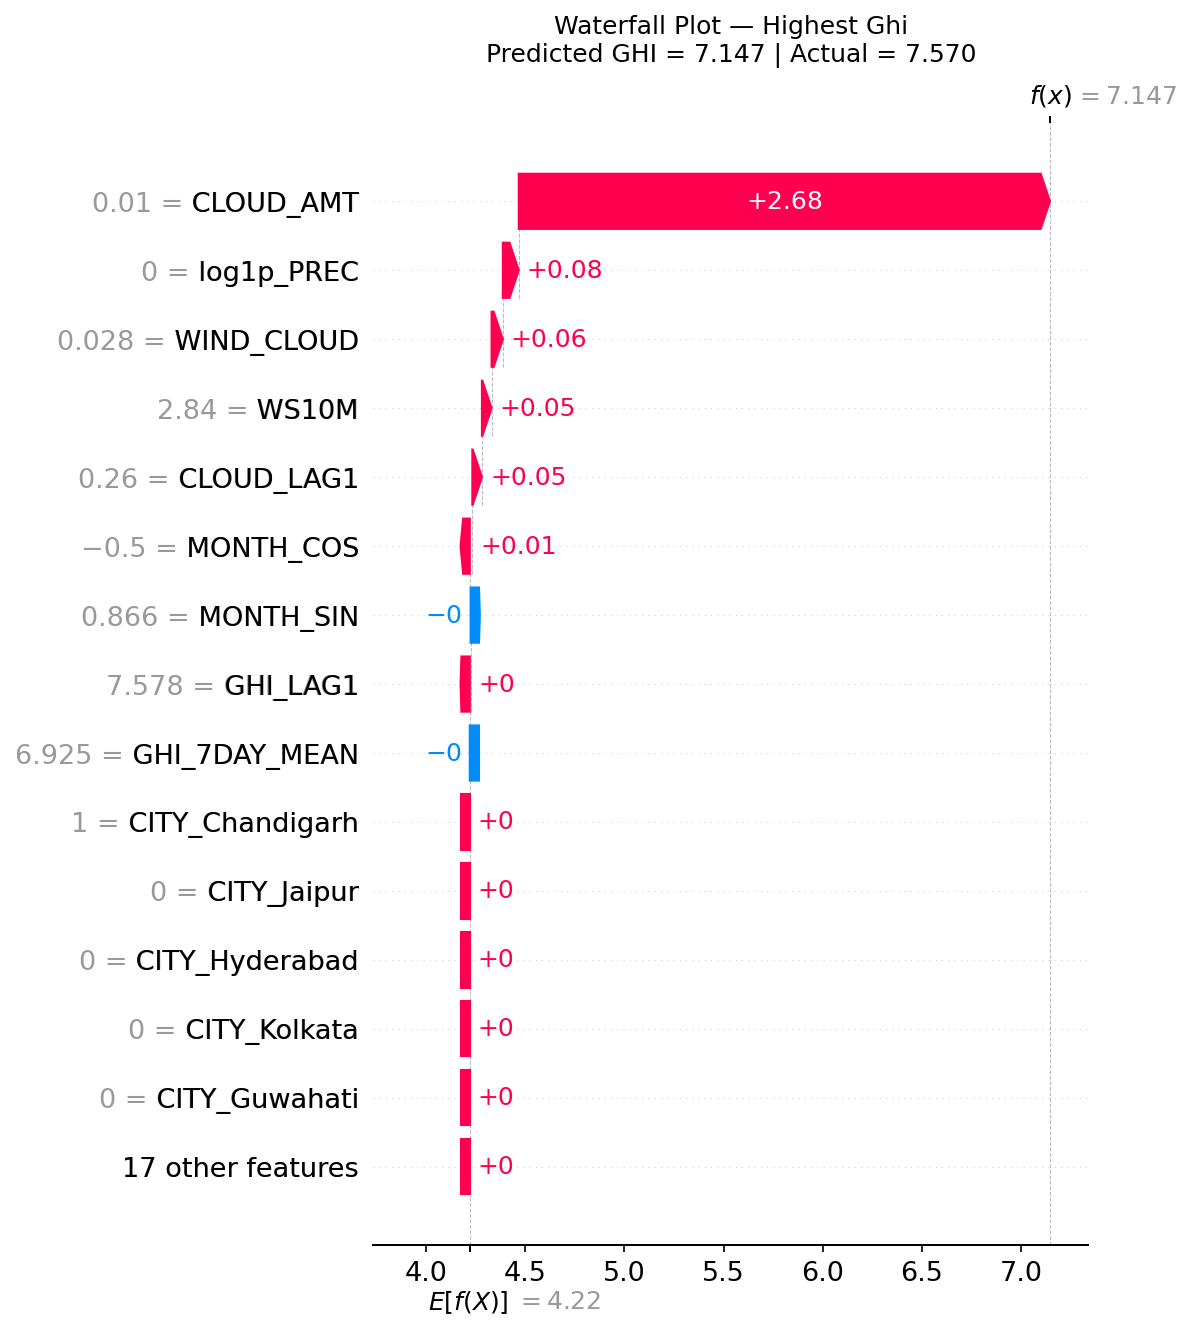

In [10]:
# Waterfall Plot: Highest GHI Day
from IPython.display import Image, display
display(Image(filename='../outputs/nb09_shap/05_waterfall_highest_GHI.png', width=800))


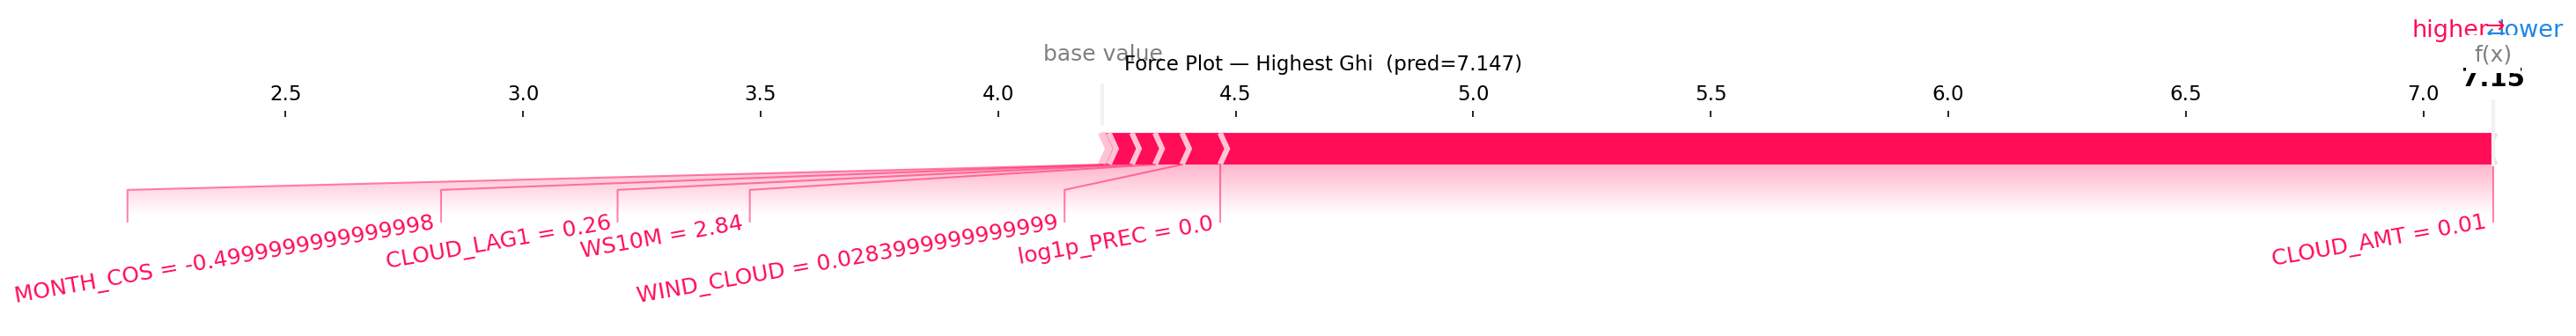

In [11]:
# Force Plot: Highest GHI Day
from IPython.display import Image, display
display(Image(filename='../outputs/nb09_shap/06_force_highest_GHI.png', width=800))


**Predicted GHI = 7.147 | Actual = 7.570 kWh/m&sup2;/day**

The dominant driver is `CLOUD_AMT = 0.01` (essentially clear sky), contributing **+2.68 kWh/m&sup2;/day** above base value. Zero precipitation (`log1p_PREC = 0`) adds +0.08. This is a Chandigarh observation during a clear, dry period. On perfect clear-sky days, cloud cover alone explains most of the deviation above the mean.

### 12.2 Lowest GHI Day


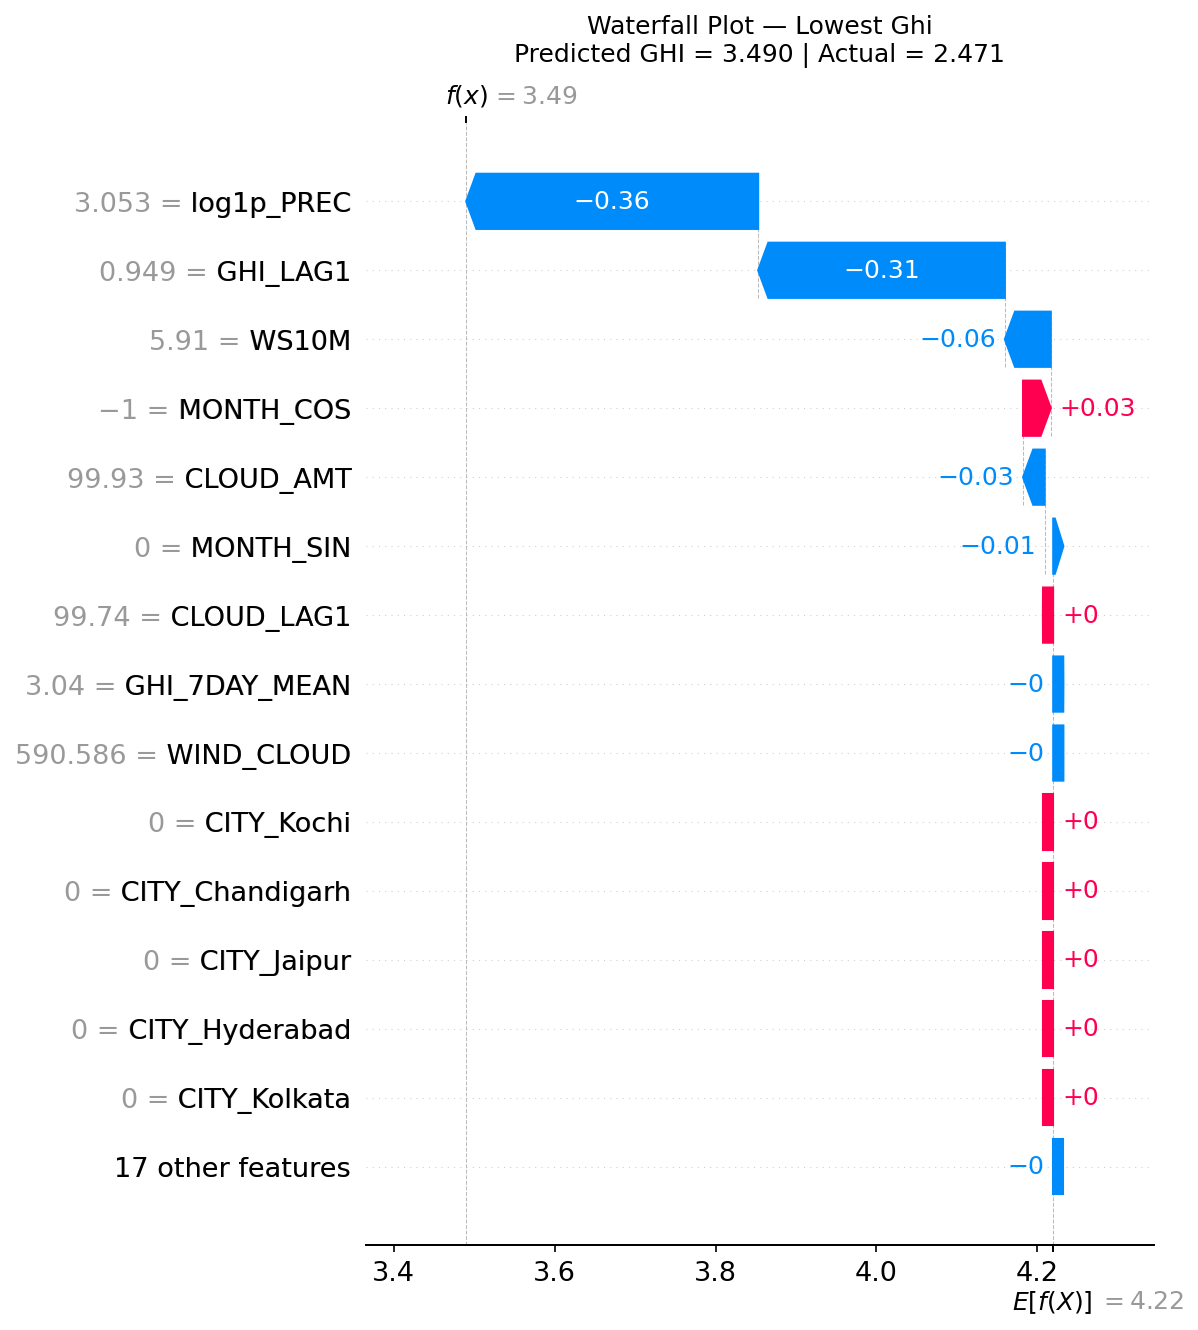

In [12]:
# Waterfall Plot: Lowest GHI Day
from IPython.display import Image, display
display(Image(filename='../outputs/nb09_shap/05_waterfall_lowest_GHI.png', width=800))


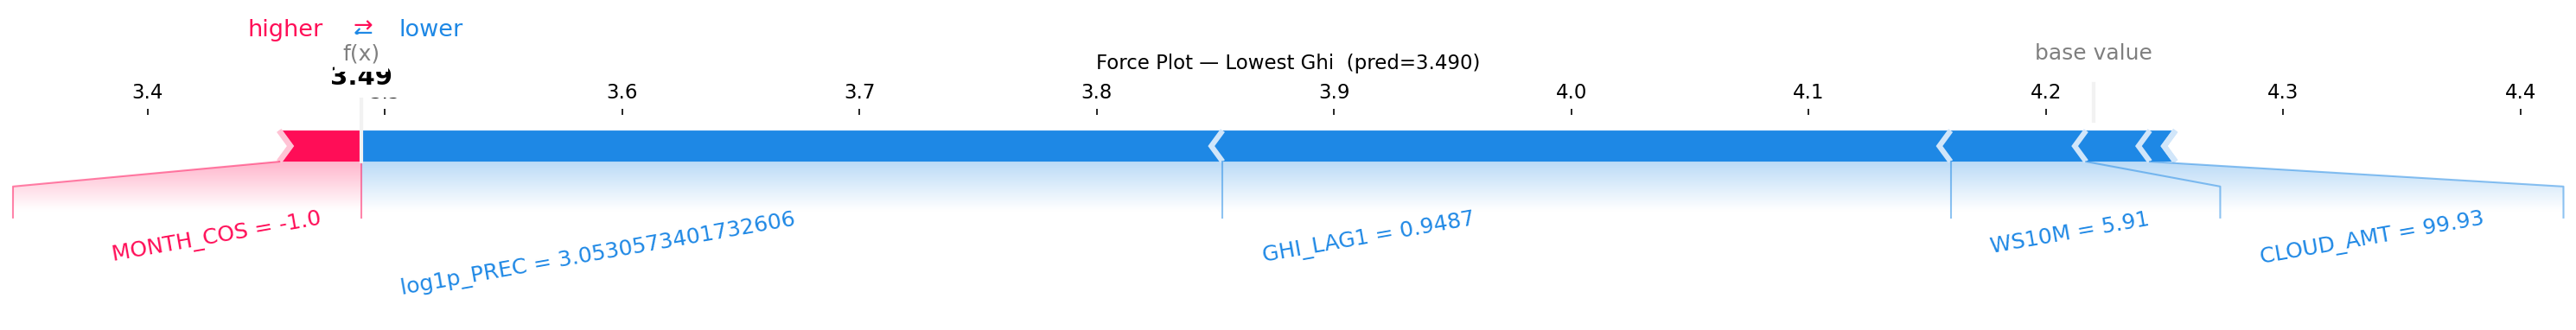

In [13]:
# Force Plot: Lowest GHI Day
from IPython.display import Image, display
display(Image(filename='../outputs/nb09_shap/06_force_lowest_GHI.png', width=800))


**Predicted GHI = 3.490 | Actual = 2.471 kWh/m&sup2;/day**

Pulled below base value by `log1p_PREC = 3.053` (heavy rainfall, &minus;0.36) and `GHI_LAG1 = 0.949` (very low yesterday GHI, &minus;0.31). Prediction error is 1.02 &mdash; the model underestimates how extreme this day was. For the absolute lowest GHI days, extreme events remain the hardest to predict.

### 12.3 Median GHI Day


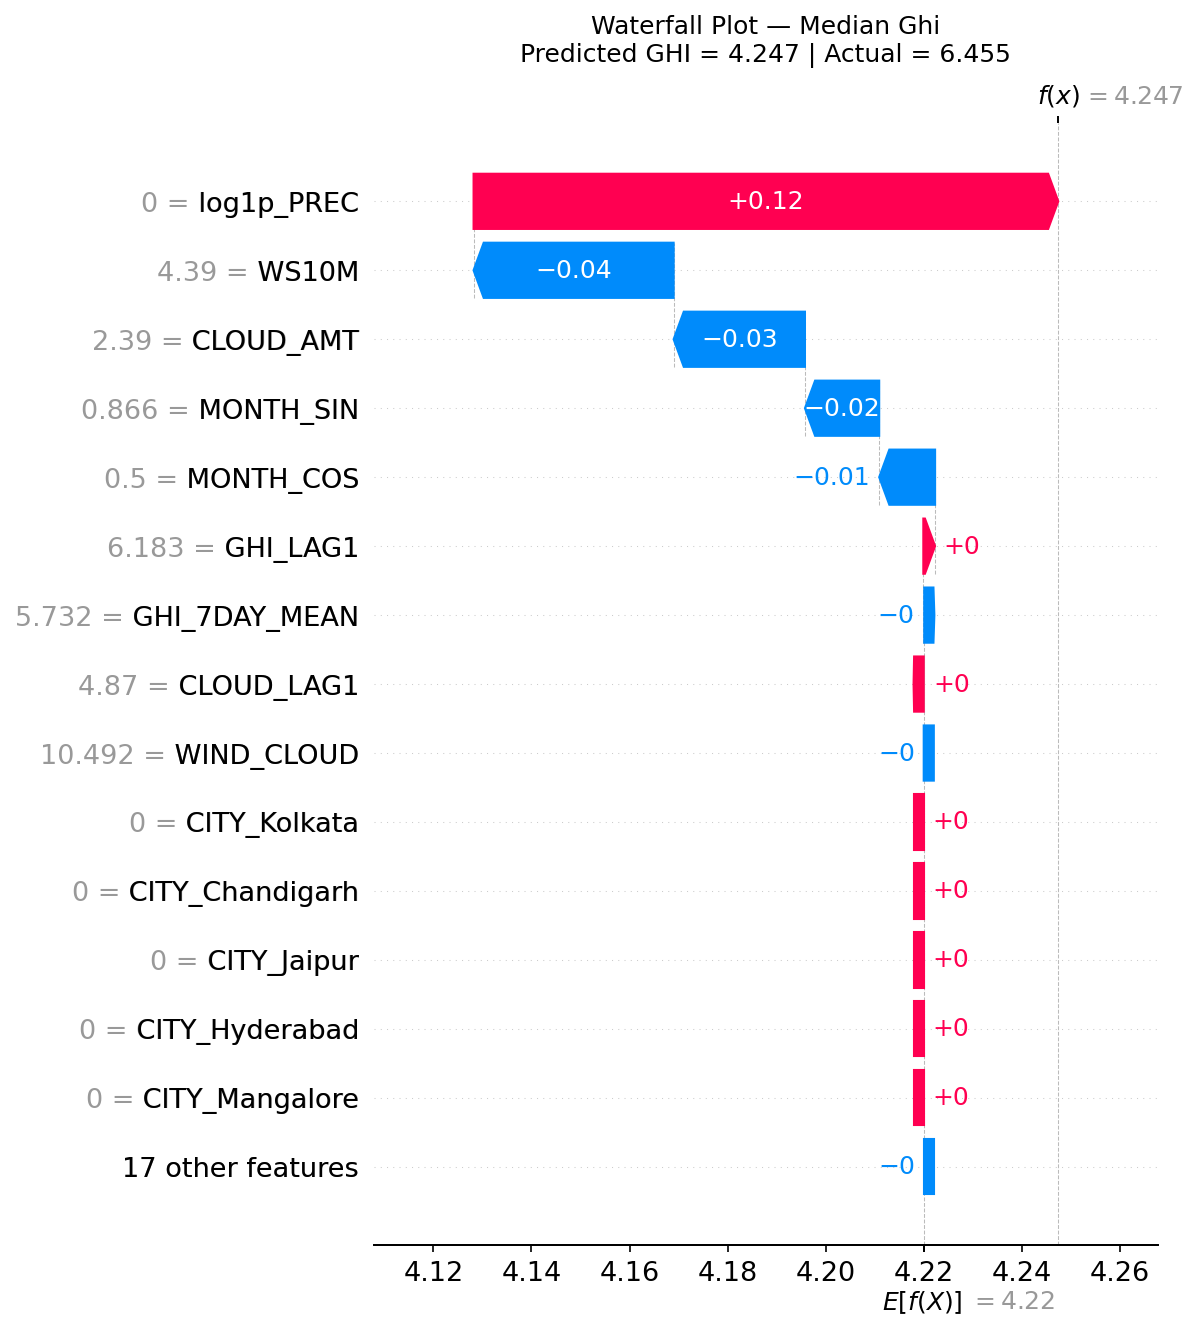

In [14]:
# Waterfall Plot: Median GHI Day
from IPython.display import Image, display
display(Image(filename='../outputs/nb09_shap/05_waterfall_median_GHI.png', width=800))


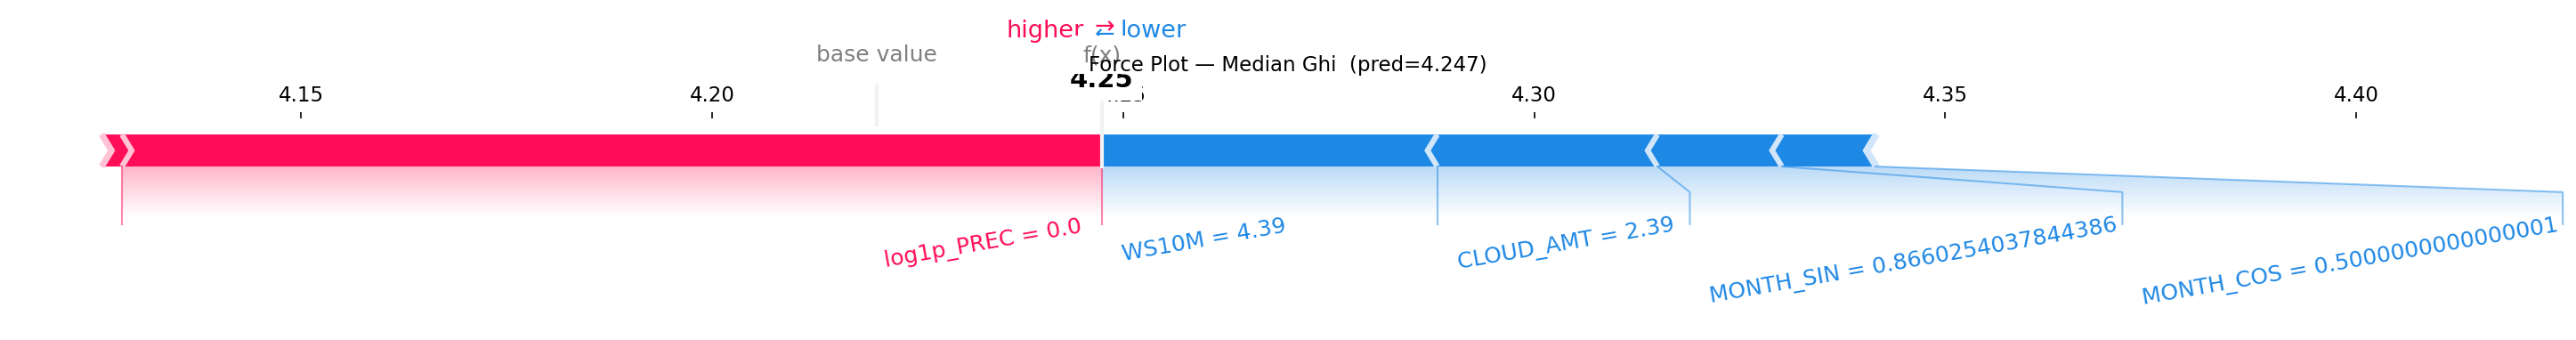

In [15]:
# Force Plot: Median GHI Day
from IPython.display import Image, display
display(Image(filename='../outputs/nb09_shap/06_force_median_GHI.png', width=800))


**Predicted GHI = 4.247 | Actual = 6.455 kWh/m&sup2;/day**

The predicted value sits close to the base value (4.22), with `log1p_PREC = 0` pushing up +0.12, partially offset by `WS10M` and `CLOUD_AMT`. The large residual (+2.21) suggests a clear-sky day the model underweighted. For average days, the model is primarily governed by the overall mean with small feature nudges in both directions.


---
## 13. Real-World Impact and Applications

### 13.1 Solar Farm Planning &amp; Site Selection

When applied across all 15 cities, the model can rank locations by mean annual GHI, monsoon season GHI (risk during lowest production months), and SHAP variance as a proxy for forecast uncertainty. Solar developers can use this ranking to prioritise survey resources and model project IRRs under different climate scenarios.

### 13.2 Energy Yield Forecasting

Accurate daily GHI predictions translate directly into energy yield estimates:

```
Daily Energy Output (kWh) = GHI_predicted x Panel_Area x Panel_Efficiency x PR
```

Where PR (Performance Ratio) accounts for inverter losses, temperature de-rating, and soiling. A 9.71% MAPE on GHI translates to approximately &plusmn;10&ndash;12% uncertainty on daily energy yield &mdash; well within the &plusmn;15% tolerance typically required for project bankability assessments.

### 13.3 Grid Management and Dispatch Planning

Distribution companies (DISCOMs) managing solar-heavy grids benefit from day-ahead GHI forecasts:
- **High GHI forecast** &rarr; reduce thermal generation; maximise solar curtailment margin
- **Low GHI forecast** &rarr; schedule backup capacity; avoid sudden ramp events
- **Monsoon onset prediction** &rarr; pre-position spinning reserves for the seasonal GHI collapse

### 13.4 Renewable Energy Policy and Optimisation

Government and MNRE planners can use multi-city GHI projections to identify under-exploited solar corridors (high mean GHI, low current installed capacity) and assess climate change impacts on future solar yield under different RCP scenarios.

### 13.5 Operations and Maintenance (O&amp;M)

The `log1p_PREC` and `CLOUD_AMT` signals can drive panel cleaning schedules &mdash; heavy rainfall events self-clean panels, while extended dry dusty periods require proactive washing.


---
## 14. Limitations

### 14.1 Spatial Resolution
NASA POWER reanalysis data is gridded at **~50 km spatial resolution**. Micro-climatic variations within a city &mdash; coastal breezes, urban heat island effects, elevated terrain &mdash; are not captured. A solar farm sited in a specific valley or coastal strip may experience significantly different conditions from the city-level grid cell.

### 14.2 Point-Location Predictions
The model predicts GHI for **city centroid coordinates**. For solar farm siting, site-specific data from meteorological stations or satellite-derived high-resolution products (e.g., NSRDB, Solargis) would provide more accurate estimates.

### 14.3 Temporal Range
Training data covers 2019&ndash;2022 (4 years), with test on 2023&ndash;2024. Long-period climate cycles (El Ni&ntilde;o/La Ni&ntilde;a, Indian Ocean Dipole) operate on multi-year timescales. The model may underperform in years with strong ENSO forcing not well-represented in the training period.

### 14.4 No Direct Diffuse Irradiance Separation
The target variable `ALLSKY_SFC_SW_DWN` is total GHI. For bifacial panels and concentrated solar power (CSP) applications, the **direct normal irradiance (DNI)** and **diffuse horizontal irradiance (DHI)** components are required separately &mdash; not addressed in this version.

### 14.5 Static City Encoding
The 15 binary city features provide a fixed offset per city. They do not capture **intra-city seasonal heterogeneity** or allow the model to generalise to new unseen cities without retraining.

### 14.6 No Real-Time Weather Inputs
The current model uses historical reanalysis data, not real-time NWP (Numerical Weather Prediction) forecasts. Operational deployment would require integration with forecast APIs (e.g., IMD, ECMWF) and retraining on forecast-vs-actual pairs.

### 14.7 Model R&sup2; Context
The test R&sup2; of 0.8831 indicates strong but not near-perfect prediction. The remaining ~11.7% unexplained variance likely reflects sub-grid spatial variability, aerosol events (dust storms, crop burning), and inherent stochasticity in cloud formation not fully captured by daily-resolution inputs.


---
## 15. Future Scope

### 15.1 Deep Learning Architectures

| Architecture | Potential Advantage |
|-------------|---------------------|
| **LSTM / GRU** | Native sequence modelling &mdash; replaces manual lag feature engineering with learned temporal context |
| **Temporal Convolutional Network (TCN)** | Parallelisable sequence modelling with dilated convolutions &mdash; faster training than LSTM |
| **Transformer (Time-Series Transformer)** | Self-attention captures long-range seasonal dependencies without explicit cyclical encoding |
| **N-BEATS / N-HiTS** | Interpretable neural architectures specifically designed for time-series decomposition |

### 15.2 Real-Time Weather Feed Integration

Connecting the model to **live NWP forecast APIs** (IMD MOSDEX, Open-Meteo, ECMWF AIFS) would convert it from a historical analysis tool into an operational **day-ahead forecasting system** &mdash; the critical step for utility-scale deployment.

### 15.3 Extended Geographic Coverage

Extending the pipeline to **100+ cities** using the same NASA POWER API, with spatial interpolation (kriging, IDW) to generate continuous GHI maps across India rather than point predictions.

### 15.4 High-Resolution Satellite Data

Integrating **INSAT-3D/3DR** satellite imagery (3 km resolution, 15-minute intervals) as model inputs would capture sub-daily GHI dynamics and enable hourly predictions.

### 15.5 Multi-Output Prediction

Extending the target to predict `DNI`, `DHI`, and panel temperature simultaneously using **multi-output XGBoost or neural networks** &mdash; enabling complete PV system simulation rather than irradiance-only forecasting.

### 15.6 Deployment as a Web Application

Packaging the trained model as a **FastAPI microservice** with a Streamlit or React front-end, allowing solar developers to query site-specific GHI forecasts and receive SHAP-based explanations interactively.

### 15.7 Transfer Learning to Unseen Cities

Applying **transfer learning** from the 15 trained cities to unseen locations using city metadata (latitude, altitude, distance to coast) as auxiliary inputs &mdash; reducing data requirements for new site assessments.


---
## 16. Final Conclusion

This project has successfully demonstrated that **machine learning can provide accurate, interpretable, and physically meaningful predictions of daily solar irradiance** across the diverse climatic landscape of India.

The end-to-end pipeline &mdash; from NASA POWER data ingestion through feature engineering, rigorous model benchmarking, XGBoost hyperparameter tuning, and SHAP explainability &mdash; has produced a model that:

1. **Achieves 88.31% variance explanation** (R&sup2; = 0.8831) on a genuinely held-out 2-year test set (2023&ndash;2024), using a strictly temporal split that prevents any information leakage from future data.

2. **Maintains interpretability** through SHAP analysis: every prediction can be decomposed into contributions from individual climate variables, with physically consistent signs and magnitudes &mdash; precipitation and cloud cover suppress GHI, lag features encode weather persistence, and seasonal variables encode the annual insolation cycle and monsoon regime.

3. **Generalises across 15 climatically diverse Indian cities** &mdash; from the arid northwest (Jaipur, Ahmedabad) to the humid tropics (Kochi, Chennai, Mangalore) &mdash; using a single unified model enabled by city one-hot encoding and the feature engineering pipeline.

4. **Exceeds all baseline models** (Linear Regression, Ridge Regression, Random Forest) across all four evaluation metrics, confirming that the non-linear gradient boosting approach is well-suited to the complex, regime-dependent nature of Indian solar irradiance.

The SHAP analysis is particularly valuable beyond model validation: it provides **actionable insights for solar energy stakeholders**. The dominance of precipitation (`log1p_PREC`) and cloud cover (`CLOUD_AMT`) as the top-2 SHAP features justifies climate-risk screening in solar project development. The strong contribution of wind speed (`WS10M`) is a non-obvious but physically grounded finding. The minimal contribution of `T2M_MAX` confirms that temperature alone is an unreliable proxy for solar resource &mdash; a counterintuitive but important result for site selection practice.

This work lays a rigorous quantitative foundation for a full **solar farm suitability recommendation system** &mdash; the logical next step being spatial aggregation of multi-city predictions, uncertainty quantification, and integration with real-time NWP forecasts for operational deployment.

---

<div style="text-align:center; padding:20px; background:#f0f4f8; border-radius:8px; border-left: 4px solid #2563eb;">
  <p style="font-size:1.1em; color:#1e293b;">
    <strong>Project completed.</strong><br>
    All notebooks (01&ndash;10), model artifacts, and SHAP outputs are preserved in the <code>outputs/</code> directory.
  </p>
  <p style="color:#64748b; font-size:0.9em;">
    Climate-Driven Solar Energy Analytics &middot; MCA Final Project &middot; BMSCE Bengaluru
  </p>
</div>
